This notebook exemplifies to procedures for generating defossilized life cycle inventory databases with "fossilfree_ecoinvent".

Importing the module

In [1]:
from fossilfree_ecoinvent.FossilfreeDatabase import FossilfreeDatabase
from pathlib import Path


Setup a FossilfreeDatabase class instance

In [2]:
ndb = FossilfreeDatabase()

You can download the "input_parameters_v391.xslx" file from the Github (https://github.com/hschlesier/fossilfree_ecoinvent/blob/new_package/notebook/Example.ipynb) and put it where you want it. Change the path below accordingly.

In [3]:
ndb.load_parameters(path=Path.cwd().parent / Path("src/fossilfree_ecoinvent/data"), filename="input_parameters_v391.xlsx")

Display the input parameters for your fossil-free ecoinvent database

In [ ]:
ndb.display_parameters()

,values
electricity_location_string,['all markets']
lorry_locations,GLO
ei_version,3.9.1
new_db_name,ecoinvent-3.9.1-cutoff_fossilfree
f_e,0.0
transf_loss,0.01
phi,"{'battery': 0.2, 'h2': 0.01, 'pumped': 0.09}"
numb_cycles,5000
discharge_depth,0.8
nu_turnaround,0.92


You can also change parameter values manually

In [5]:
#for example: changing the remaining fossil electricity inputs in electricity markets
ndb.f_e = 0.2 #share of fossil electricity input remaining
ndb.display_parameters()
ndb.f_e = 0

,values
electricity_location_string,['all markets']
lorry_locations,GLO
ei_version,3.9.1
new_db_name,ecoinvent-3.9.1-cutoff_fossilfree
f_e,0.2
transf_loss,0.01
phi,"{'battery': 0.2, 'h2': 0.01, 'pumped': 0.09}"
numb_cycles,5000
discharge_depth,0.8
nu_turnaround,0.92


Then define your project name and use your ecoinvent login credentials to import a default ecoinvent database

In [ ]:
project = 'FFEI_391_package_test' #put brightway project name

#Your ecoinvent login data for loading ecoinvent databases
username = 'username' #<---- replace with your ecoinvent username
password = 'password' #<---- replace with your ecoinvent password
ndb.setup(project=project,
          username=username, 
          password=password, 
          overwrite=False) #True: overwrites existing ecoinvent database


"\n\nproject = 'FFEI_391_package_test' #put brightway project name\n\n#Your ecoinvent login data for loading ecoinvent databases\nusername = 'username' #<---- replace with your ecoinvent username\npassword = 'password' #<---- replace with your ecoinvent password\nndb.setup(project=project,\n          username=username, \n          password=password, \n          overwrite=False) #True: overwrites existing ecoinvent database\n"

In [98]:
import bw2data as bd
bd.databases

Databases dictionary with 3 object(s):
	biosphere3
	ecoinvent-3.9.1-cutoff
	ecoinvent-3.9.1-cutoff_fossilfree

The new database is now setup and we can add addional datasets for electric vehicles and alternative fuels

In [99]:
ndb.add_inventories('lci-synfuels')

----
Electric passenger cars already in database
----
----
Electric lorries already in database
----
Merged with carculator db and carculator_truck db.
Synfuel already in database:  ecoinvent-3.9.1-cutoff_fossilfree
Added new diesel market and biocoke market.


Now that the database is setup and additional datasets are included, we can start the defossilization process: Let us start with the electricity sector.

You can define a list of individual countries (using country codes) or target all available markets. For the latter 'all markets' needs to specified in the input parameter file.

In [100]:
print(ndb.electricity_location_string)
ndb.electricity_locations

['all markets']


['EG',
 'CA-NS',
 'US-SERC',
 'IL',
 'IN-Eastern grid',
 'CA-ON',
 'CA-NF',
 'CN-CSG',
 'IR',
 'IE',
 'TH',
 'HU',
 'GH',
 'KH',
 'US-ASCC',
 'KE',
 'BJ',
 'TN',
 'SY',
 'PE',
 'TW',
 'GB',
 'EC',
 'PY',
 'AE',
 'UZ',
 'TZ',
 'MD',
 'UA',
 'MX',
 'TG',
 'KW',
 'NO',
 'LY',
 'VN',
 'CA-NT',
 'CO',
 'IS',
 'CA-MB',
 'LV',
 'CA-PE',
 'US-HICC',
 'CN-NECG',
 'KG',
 'NI',
 'PK',
 'CR',
 'BO',
 'CD',
 'AO',
 'BE',
 'AL',
 'AR',
 'CN-ECGC',
 'CA-BC',
 'DE',
 'BY',
 'CW',
 'LT',
 'SN',
 'AM',
 'AZ',
 'ET',
 'NL',
 'CN-NWG',
 'PA',
 'HR',
 'JP',
 'BA',
 'BH',
 'BD',
 'KZ',
 'IN-North-eastern grid',
 'CL',
 'CA-SK',
 'CA-AB',
 'BR-Northern grid',
 'CM',
 'NA',
 'CZ',
 'DO',
 'SE',
 'HN',
 'BW',
 'CI',
 'AU',
 'SD',
 'IN-Western grid',
 'MZ',
 'TJ',
 'GR',
 'GI',
 'CH',
 'PH',
 'US-PR',
 'SK',
 'RU',
 'GE',
 'MM',
 'EE',
 'BG',
 'SV',
 'IT',
 'GA',
 'NG',
 'IN-Northern grid',
 'ER',
 'QA',
 'TT',
 'MU',
 'UY',
 'FI',
 'MA',
 'US-TRE',
 'CG',
 'ES',
 'CA-NU',
 'NE',
 'MY',
 'IN-Southern grid',
 'I

For convenience, let us start with just one country.

In [108]:
ndb.electricity_locations = ['MN'] #now only the mongolian grid would be modified
ndb.defossilize_electricity()

Treating electricity markets.
Treating activities: [------------------------------------------------->] 100% current market: MN           
--------------------
Electricity defossilized!
--------------------


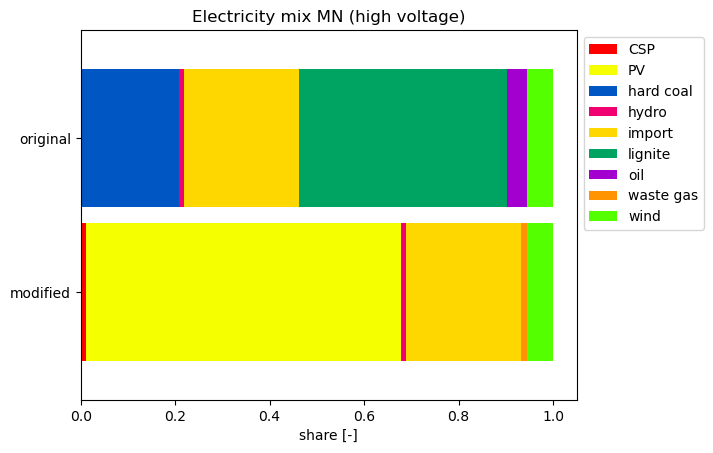

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

location = ndb.electricity_locations[0]

og_grid_ = [act for act in ndb.base_db if act['name']=='market for electricity, high voltage'
                                and act['location']==location
                                ][0]

ff_grid_ = [act for act in ndb.fossilfree_db if act['name']=='market for electricity, high voltage'
                                and act['location']==location
                                ][0]

def get_type(name):
    typ = name.split(', ')[1]
    if 'PV' in name:
      typ='PV'
    elif 'high voltage' in typ:
      typ='import'
    elif 'power plant' in typ:
      typ='waste gas'
    elif 'parabolic' in typ:
      typ='CSP' 
    return typ

def get_mix(act):
    mix_tuples = [(get_type(exc.input['name']), exc.amount) for exc in act.technosphere() 
                    if exc.input['unit']=='kilowatt hour']
    df = pd.DataFrame(mix_tuples, columns=['source', 'value']).sort_values('value')
    return df.set_index('source').groupby('source').sum()/sum(df.value)

og_mix, ff_mix = [get_mix(act) for act in [ff_grid_, og_grid_]]

fig, ax = plt.subplots(1,1)
pd.concat([og_mix, ff_mix],axis=1).T.plot.barh(ax=ax, stacked=True, cmap='prism', width=0.9)
ax.set_yticklabels(['modified', 'original'])
ax.legend(bbox_to_anchor=(1, 1))
ax.set_xlabel('share [-]')
ax.set_title('Electricity mix {} (high voltage)'.format(location))

plt.show()

Remember that we specified 20% of fossils should remain. Next is defossilizing heat.

In [110]:
ndb.defossilize_heat()

Treating heat markets...
Added biomethane market
Added heat process with electric resistor.
Creating market for heat, 60-100 °C, 10-100 kW
Creating market for heat, 60-100 °C, 100-1000 kW
Creating market for heat, 60-100 °C, 1-10 MW
Creating market for heat, 60-100 °C, 1-10 kW
Creating market for heat, 60-100 °C, 100-1000 MW
Creating market for heat, 100-200 °C, 10-100 kW
Creating market for heat, 100-200 °C, 100-1000 kW
Creating market for heat, 100-200 °C, 1-10 kW
Creating market for heat, 200-400 °C, 100-1000 kW
Creating market for heat, 200-400 °C, 1-10 MW
Creating market for heat, >400 °C, 100-1000 kW
Creating market for heat, >400 °C, 1-10 MW
Set up new heat markets.
Importing heat substitution matrix.
Allocating fossil heat processes to renewable ones.
No fossil heat processes to substitute at this level: 100-200 °C 100-1000 kW
No fossil heat processes to substitute at this level: 100-200 °C 1-10 kW
No fossil heat processes to substitute at this level: 200-400 °C 100-1000 kW
Mat

100%|██████████| 428/428 [00:55<00:00,  7.68it/s]

Scaled heat exchanges.
------------------------------------
Heat processes defossilized!
------------------------------------


Great! Now, let us turn to transport.

In [111]:
ndb.defossilize_transport()

Creating electric lorry markets.
Creating markets for transport, freight, electric lorry.
Creating electric lorry production with refrigeration.
Creating transport, freight, electric lorry with refrigeration machine.
Successfully switched activity dataset to new code `4365f7632bd5425fa981b5412ecb78ee`
Successfully switched activity dataset to new code `fd107d15e0b74ed7a9349d585b41ff9a`
Successfully switched activity dataset to new code `b122c6ddb5a14e8c9a49697ed4314b76`
Successfully switched activity dataset to new code `50ef8a5c00334dd6a80396b81025a3b4`
Successfully switched activity dataset to new code `e17cd7b75625418dbb70022c2d25893e`
Successfully switched activity dataset to new code `119ac3e2a9d9462295dc1ad3ec43c9d4`
Successfully switched activity dataset to new code `1ec91f9705224732b4a4d5f6428bd893`
Successfully switched activity dataset to new code `74f17b75b2294d0c9e2b6c43f68ec297`
Successfully switched activity dataset to new code `3574547a92ee4196899eca521431a5dc`
Successfu

And lastly, let us target all other processes

In [112]:
ndb.defossilize_other()

Defossilizing several processes with fossil fuel input.
Treating consumers: [------------------------------------------------->] 100% current: market for pitch                  re                                   
Creating fossil-fuel free carbon anodes for aluminium electrolsysis.
Successfully switched activity dataset to new code `15f0d7037bc54426a49e32880cccea30`
Successfully switched activity dataset to new code `077c9965da33400bba94517b4f516296`
Successfully switched activity dataset to new code `40749e2140f34508b57c92c8ba0b67b3`
Successfully switched activity dataset to new code `0d1ccae4fa7e4f1eb154991c8bd14252`
Successfully switched activity dataset to new code `b47115469fd445c9818bc83b17385c61`
Successfully switched activity dataset to new code `4636d01649ed417bab67dae8d5c4a70a`
Successfully switched activity dataset to new code `470e66b83c60478badbe3ca9c5ac9a9b`
Successfully switched activity dataset to new code `48e8dc2c0f0e43b0b5bdc5c1ff45711e`
Successfully switched activi

Defossilization of electricity, heat, transport, and other processes can also be done with a single function

In [ ]:
ndb.defossilize_all()

Ultimately, run checks and balances.

In [113]:
ndb.run_checks_and_balances()

Run checks and balances.


100%|██████████| 707/707 [00:24<00:00, 28.35it/s]


Checked whether all exchanges link to self.
Added production amount for 20 activities.
Adding classifications to database...
Added 765 classifications in ecoinvent-3.9.1-cutoff_fossilfree
Finished classifications
Checking production...


100%|██████████| 21945/21945 [00:15<00:00, 1455.53it/s]


Finished check. Added 209 productions


100%|██████████| 21945/21945 [13:38<00:00, 26.82it/s] 


Adjusted uncertainties for all activities.
Clean database from zero amount flows.


100%|██████████| 21945/21945 [00:17<00:00, 1246.94it/s]


The changes applied to activities can be checked in the change report

In [114]:
ndb.save_change_report()

Generating change report.
Saved change report under:
/Users/haukeschlesier/FFEI/data/results/change_report.xlsx


Modifying country electricity markets uniquely

It is possible to modify each country's electricity mix seperately by redefining the electricity parameters while looping trough the countries.

In [116]:
import electricity as ele
from electricity import treat_electricity_markets

ndb.f_e = 0

country_code = 'JP' #example for Japan

new_electricity_split_dict = {
country_code:
{
 'PV': 0.2,
 'Wind onshore': 0.12,
 'Wind offshore': 0.11,
 'Hydro': 0.025,
 'Geothermal': 0.205,
 'Biomass': 0.005,
 'Nuclear': 0.305,
 'Solar': 0.03
 }
}

for country_code in new_electricity_split_dict.keys():
    ndb.electricity_split = new_electricity_split_dict[country_code]

    ndb.altered_activities = ele.treat_electricity_markets(
                                  database = ndb.fossilfree_db,
                                  locations = [country_code],
                                  transformation_losses = ndb.transf_loss,
                                  phi = ndb.phi,
                                  numb_cycles = ndb.numb_cycles,
                                  discharge_depth = ndb.discharge_depth,
                                  ei_version = ndb.ei_version,
                                  nu_turnaround = ndb.nu_turnaround,
                                  d = ndb.d,
                                  fossil_reduction_factor = ndb.f_e,
                                  fossil_identifiers = ndb.fossil_identifier,
                                  altered_activities = ndb.altered_activities,
                                  electricity_split = ndb.electricity_split,
                                  nu_fuel_cell = ndb.nu_fuel_cell,
                                  scale_non_market_locations= False #skip
                                 )

Treating electricity markets.
Treating activities: [------------------------------------------------->] 100% current market: JP           
--------------------
Electricity defossilized!
--------------------


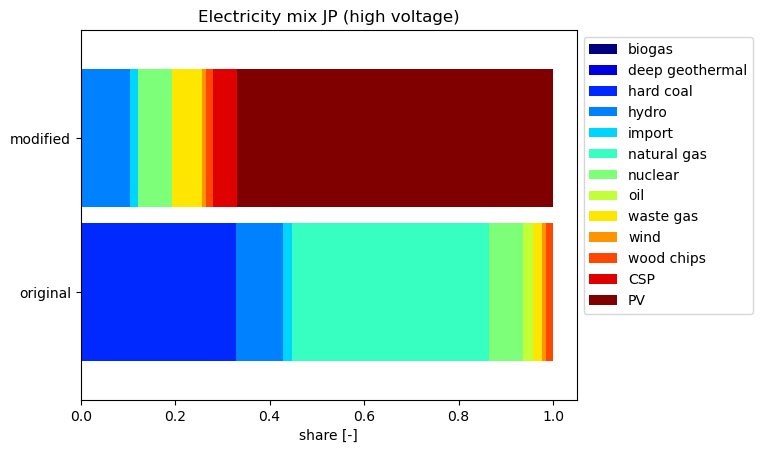

In [117]:

country_code = 'JP'

og_grid = [act for act in ndb.base_db if act['name']=='market for electricity, high voltage'
                                and act['location']==country_code
                                ][0]

ff_grid = [act for act in ndb.fossilfree_db if act['name']=='market for electricity, high voltage'
                                and act['location']==country_code
                                ][0]

def get_type(name):
    typ = name.split(', ')[1]
    if 'PV' in name:
      typ='PV'
    elif 'high voltage' in typ:
      typ='import'
    elif 'power plant' in typ:
      typ='waste gas'
    elif 'parabolic' in typ:
      typ='CSP' 
    return typ

def get_mix(act):
    mix_tuples = [(get_type(exc.input['name']), exc.amount) for exc in act.technosphere() 
                    if exc.input['unit']=='kilowatt hour']
    df = pd.DataFrame(mix_tuples, columns=['source', 'value'])
    return df.set_index('source').groupby('source').sum()/sum(df.value)

og_mix, ff_mix = [get_mix(act) for act in [og_grid, ff_grid]]

fig, ax = plt.subplots(1,1)
pd.concat([og_mix, ff_mix],axis=1).T.plot.barh(ax=ax, stacked=True, cmap='jet', width=0.9)
ax.set_yticklabels(['original', 'modified'])
ax.legend(bbox_to_anchor=(1, 1))
ax.set_xlabel('share [-]')
ax.set_title('Electricity mix {} (high voltage)'.format(country_code))

plt.show()